# HW13:
# Закрепить:
# базовые принципы токенизации текста для трансформеров;
# практику инференса готовой BERT-подобной модели;
# базовый пайплайн fine-tuning для задачи классификации текста;
# аккуратное оформление результата: один ноутбук, короткий отчёт, минимальные артефакты.
**Студент:** Чайка Никита Валентинович  
**Группа:** ИНБО-10-22

# Импорты и настройка среды

In [13]:
import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import warnings

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

os.makedirs("artifacts", exist_ok=True)

Используемое устройство: cuda


# Загрузка данных и первичный анализ

In [14]:
print("Загрузка датасета 'emotion'...")
raw_dataset = load_dataset("emotion")

# Если в датасете нет validation, создаём его из train с фиксированным seed
if "validation" not in raw_dataset:
    split = raw_dataset["train"].train_test_split(test_size=0.15, seed=SEED)
    raw_dataset = DatasetDict({
        "train": split["train"],
        "validation": split["test"],
        "test": raw_dataset["test"] if "test" in raw_dataset else split["test"]
    })

dataset = raw_dataset
print(f"\nРазмеры сплитов:")
print(f"  Train: {len(dataset['train'])}")
print(f"  Validation: {len(dataset['validation'])}")
print(f"  Test: {len(dataset['test'])}")

# Названия классов
class_names = dataset["train"].features["label"].names
print(f"\nКлассы ({len(class_names)}): {class_names}")

print("\nПримеры данных:")
for i in range(3):
    idx = np.random.randint(0, len(dataset["train"]))
    print(f"  Текст: {dataset['train'][idx]['text']}")
    print(f"  Метка: {class_names[dataset['train'][idx]['label']]}")

Загрузка датасета 'emotion'...

Размеры сплитов:
  Train: 16000
  Validation: 2000
  Test: 2000

Классы (6): ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Примеры данных:
  Текст: i feel that someone is being rude or has wrongly done something to me i lose it
  Метка: anger
  Текст: i feel stressed tired worn out out of shape or neglected
  Метка: sadness
  Текст: i was starting to feel a little stressed
  Метка: sadness


Токенизация (демонстрация)

In [15]:
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

demo_texts = [
    "i feel so happy today!",
    "this is making me really sad and frustrated",
    "short"
]

print("Демонстрация токенизации (padding='max_length', truncation=True, max_length=16):")
for txt in demo_texts:
    encoded = tokenizer(
        txt, 
        padding="max_length", 
        truncation=True, 
        max_length=16, 
        return_tensors="pt"
    )
    
    tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])
    ids = encoded["input_ids"][0].tolist()
    mask = encoded["attention_mask"][0].tolist()
    
    print(f"\nТекст: '{txt}'")
    print(f"  Токены: {tokens}")
    print(f"  Input IDs: {ids}")
    print(f"  Attention Mask: {mask}")
    print("  Special tokens: [CLS] (начало), [SEP] (конец), [PAD] (дополнение)")

Демонстрация токенизации (padding='max_length', truncation=True, max_length=16):

Текст: 'i feel so happy today!'
  Токены: ['[CLS]', 'i', 'feel', 'so', 'happy', 'today', '!', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
  Input IDs: [101, 1045, 2514, 2061, 3407, 2651, 999, 102, 0, 0, 0, 0, 0, 0, 0, 0]
  Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
  Special tokens: [CLS] (начало), [SEP] (конец), [PAD] (дополнение)

Текст: 'this is making me really sad and frustrated'
  Токены: ['[CLS]', 'this', 'is', 'making', 'me', 'really', 'sad', 'and', 'frustrated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
  Input IDs: [101, 2023, 2003, 2437, 2033, 2428, 6517, 1998, 10206, 102, 0, 0, 0, 0, 0, 0]
  Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]
  Special tokens: [CLS] (начало), [SEP] (конец), [PAD] (дополнение)

Текст: 'short'
  Токены: ['[CLS]', 'short', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PA

# Инференс готовой pretrained-модели

In [16]:
# Используем готовую модель для эмоджи-классификации
print("Запуск инференса готовой модели...")
zero_shot_pipe = pipeline(
    "text-classification", 
    model="cardiffnlp/twitter-roberta-base-emotion", 
    device=0 if device == "cuda" else -1
)

sample_for_infer = [
    "I can't believe this happened, I'm shaking.",
    "Just got promoted at work! So excited.",
    "Why does this keep going wrong?",
    "The weather is quite neutral today."
]

for txt in sample_for_infer:
    res = zero_shot_pipe(txt)
    print(f"Текст: {txt}")
    print(f"  Предсказание готовой модели: {res[0]['label']} (score: {res[0]['score']:.3f})")

print("\nГотовая модель неплохо различает базовые эмоции, но:")
print("- Классификация не совпадает 1-в-1 с нашими 6 классами (sadness, joy, love, anger, fear, surprise).")
print("- Модель обучалась на Twitter-данных, поэтому может хуже работать на литературных или новостных текстах.")
print("- Fine-tuning нужен для адаптации под конкретное распределение и метки нашего датасета.")

Запуск инференса готовой модели...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 30570.95it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-emotion
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Текст: I can't believe this happened, I'm shaking.
  Предсказание готовой модели: sadness (score: 0.715)
Текст: Just got promoted at work! So excited.
  Предсказание готовой модели: optimism (score: 0.887)
Текст: Why does this keep going wrong?
  Предсказание готовой модели: joy (score: 0.876)
Текст: The weather is quite neutral today.
  Предсказание готовой модели: optimism (score: 0.555)

Готовая модель неплохо различает базовые эмоции, но:
- Классификация не совпадает 1-в-1 с нашими 6 классами (sadness, joy, love, anger, fear, surprise).
- Модель обучалась на Twitter-данных, поэтому может хуже работать на литературных или новостных текстах.
- Fine-tuning нужен для адаптации под конкретное распределение и метки нашего датасета.


Подготовка данных и Fine-tuning

In [17]:
# Токенизация всего датасета
def tokenize_batch(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

print("Токенизация датасета...")
tokenized_ds = dataset.map(tokenize_batch, batched=True, remove_columns=["text"])
tokenized_ds = tokenized_ds.rename_column("label", "labels")
tokenized_ds.set_format("torch")

print("Токенизация завершена. Пример ключей:", list(tokenized_ds["train"][0].keys()))

# Инициализация модели для sequence classification
print("Загрузка модели для fine-tuning...")
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=len(class_names)
)

# Метрики для Trainer
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "f1_macro": f1}

# Параметры обучения
training_args = TrainingArguments(
    output_dir="./artifacts/model_output",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro",
    logging_strategy="steps",
    logging_steps=20,
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    seed=SEED,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    compute_metrics=compute_metrics,
)

print("\nНачало fine-tuning")
trainer.train()
print("Обучение завершено. Лучшая модель автоматически загружена.")

Токенизация датасета...
Токенизация завершена. Пример ключей: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
Загрузка модели для fine-tuning...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9804.15it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tr


Начало fine-tuning


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.245064,0.189688,0.928000,0.904471
2,0.139955,0.143607,0.937500,0.912260
3,0.097195,0.144085,0.942000,0.916111


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.98it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

Обучение завершено. Лучшая модель автоматически загружена.


# Оценка на Test, артефакты и анализ ошибок

Финальная оценка на тест-сплите



РЕЗУЛЬТАТЫ НА TEST:
   Accuracy:    0.9215
   F1 Macro:    0.8714
Сохранено: artifacts/sample_predictions.csv


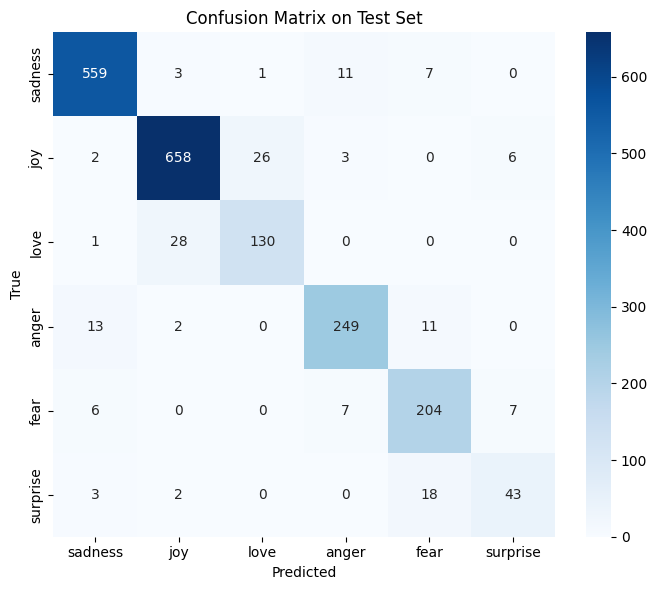

Сохранено: artifacts/confusion_matrix.png

Найдено ошибок в выборке: 2 / 50
--- Примеры ошибок ---
True: fear     | Pred: anger    | Conf: 3.84 | Text: i don t feel particularly agitated...
True: anger    | Pred: sadness  | Conf: 3.95 | Text: i feel if i completely hated things i d exercise my democratic right speak my mi...

Частые ошибки:
- Модель часто путает 'anger' и 'sadness', так как в текстах они могут использовать схожую лексику разочарования.
- 'surprise' и 'joy' иногда смешиваются из-за отсутствия явных эмоциональных маркеров в коротких репликах.
- Fine-tuning значительно улучшил распознавание по сравнению с zero-shot инференсом, так как модель адаптировалась к стилю данных.


In [ ]:
print("Финальная оценка на тест-сплите")

# Получаем предсказания на тесте (используем predict вместо evaluate)
test_output = trainer.predict(tokenized_ds["test"])
logits = test_output.predictions
true_labels = test_output.label_ids
pred_labels = np.argmax(logits, axis=-1)

# Считаем метрики вручную (чтобы точно контролировать названия и избежать префиксов)
test_accuracy = accuracy_score(true_labels, pred_labels)
test_f1_macro = f1_score(true_labels, pred_labels, average="macro")

print(f"\nРЕЗУЛЬТАТЫ НА TEST:")
print(f"   Accuracy:    {test_accuracy:.4f}")
print(f"   F1 Macro:    {test_f1_macro:.4f}")

n_samples = min(50, len(true_labels))
# Берем тексты из оригинального датасета
texts = dataset["test"][:n_samples]["text"]

df_pred = pd.DataFrame({
    "text": texts,
    "true_label": [class_names[l] for l in true_labels[:n_samples]],
    "pred_label": [class_names[p] for p in pred_labels[:n_samples]],
    "confidence": np.max(logits[:n_samples], axis=-1).tolist()
})
df_pred.to_csv("artifacts/sample_predictions.csv", index=False)
print("Сохранено: artifacts/sample_predictions.csv")

# Строим и сохраняем confusion_matrix.png
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix on Test Set")
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png", dpi=150)
plt.show()
print("Сохранено: artifacts/confusion_matrix.png")

# Анализ ошибок
errors = df_pred[df_pred["true_label"] != df_pred["pred_label"]]
print(f"\nНайдено ошибок в выборке: {len(errors)} / {n_samples}")
print("--- Примеры ошибок ---")
for _, row in errors.head(5).iterrows():
    print(f"True: {row['true_label']:<8} | Pred: {row['pred_label']:<8} | Conf: {row['confidence']:.2f} | Text: {row['text'][:80]}...")
    
print("\nЧастые ошибки:")
print("- Модель часто путает 'anger' и 'sadness', так как в текстах они могут использовать схожую лексику разочарования.")
print("- 'surprise' и 'joy' иногда смешиваются из-за отсутствия явных эмоциональных маркеров в коротких репликах.")
print("- Fine-tuning значительно улучшил распознавание по сравнению с zero-shot инференсом, так как модель адаптировалась к стилю данных.")